<a href="https://colab.research.google.com/github/esthy13/cil-intrusion-detection/blob/main/notebooks/0_data_cleaning_UNSWNB15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration Summary (UNSW-NB15)

In [110]:
from google.colab import userdata
token = userdata.get('GIT_TOKEN')
username = userdata.get('USERNAME')
email = userdata.get('EMAIL')
!git config --global user.email {email}
!git config --global user.name {username}
repo = "cil-intrusion-detection"

In [111]:
!git clone https://{token}@github.com/{username}/{repo}
%cd {repo}
!git pull origin main

fatal: destination path 'cil-intrusion-detection' already exists and is not an empty directory.
/content/cil-intrusion-detection
From https://github.com/esthy13/cil-intrusion-detection
 * branch            main       -> FETCH_HEAD
Already up to date.


UNSW-NB15 Dataset Exploration Summary

In this project, we performed an exploratory data analysis (EDA) on the UNSW-NB15 dataset to understand its structure, labels, feature types, and suitability for a Class-Incremental Learning (CIL) based Intrusion Detection System.

Dataset Structure

The dataset is provided with predefined training and testing splits:

Training set: 175,341 samples

Testing set: 82,332 samples

Total columns: 45

A comparison of column names confirmed that the training and test sets share an identical schema, allowing the same preprocessing pipeline to be applied consistently to both.

In [112]:
import pandas as pd

train_path = "data/raw/UNSW_NB15_training-set.csv"
test_path  = "data/raw/UNSW_NB15_testing-set.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

Train shape: (175341, 45)
Test shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [113]:
train = train.drop("id", axis=1)
test = test.drop("id", axis=1)

In [114]:
train.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,6.712056e+05,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,2.421312e+06,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,1.447023e+03,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,2.784487e+04,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,2.242273e+07,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [115]:
print(train.columns)

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


In [116]:
train[['label', 'attack_cat']].head()

,label,attack_cat
0,0,Normal
1,0,Normal
2,0,Normal
3,0,Normal
4,0,Normal


In [117]:
print(train['label'].value_counts())
print(train['attack_cat'].value_counts())


label
1    119341
0     56000
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [118]:
train = train[~train["attack_cat"].isin(["Worms"])]
test = test[~test["attack_cat"].isin(["Worms"])]

In [119]:
print(train.duplicated().sum())
print(test.duplicated().sum())

67598
26387


In [120]:
train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

In [121]:
set(train.columns) - set(test.columns)
# checking if there is the same number of columns in both sets

set()

In [122]:
set(test.columns) - set(train.columns)


set()

In [123]:
missing = train.isnull().sum()
missing[missing > 0]

,0


In [124]:
import numpy as np

inf_counts = np.isinf(train.select_dtypes(include=[float, int])).sum()
inf_counts[inf_counts > 0]

,0


In [125]:
constant_cols = [c for c in train.columns if train[c].nunique() == 1]
constant_cols

[]

In [126]:
train.dtypes


,0
dur,float64
proto,object
service,object
state,object
spkts,int64
dpkts,int64
sbytes,int64
dbytes,int64
rate,float64
sttl,int64


In [127]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Number of categorical:", len(categorical_cols))
print("Number of numerical:", len(numerical_cols))

Categorical columns: ['proto', 'service', 'state', 'attack_cat']
Number of categorical: 4
Number of numerical: 40


In [128]:
print(train['service'].value_counts())

service
-           64935
http        18024
dns         11046
smtp         5025
ftp-data     3282
ftp          2691
ssh          1295
pop3         1104
snmp           63
ssl            56
dhcp           55
irc            25
radius         12
Name: count, dtype: int64


In [129]:
print(train['state'].value_counts())

state
FIN    74368
INT    19711
CON    12485
REQ      953
RST       83
ECO       10
PAR        1
URN        1
no         1
Name: count, dtype: int64


In [130]:
print(train['proto'].value_counts())

proto
tcp     76181
udp     23012
unas     2582
ospf      775
arp       633
        ...  
tlsp       26
ggp        24
igmp       17
icmp       13
rtp         1
Name: count, Length: 133, dtype: int64


In [131]:
set(train.columns) - set(test.columns)
train_features= train.drop(['proto', 'service', 'state', 'label'], axis=1)
test_features = test.drop(['proto', 'service', 'state', 'label'], axis=1)
train_features.head()

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.121478,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,...,1,1,1,0,0,0,1,1,0,Normal
1,0.649902,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,...,1,1,2,0,0,0,1,6,0,Normal
2,1.623129,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,...,1,1,3,0,0,0,2,6,0,Normal
3,1.681642,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,...,1,1,3,1,1,0,2,1,0,Normal
4,0.449454,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,...,2,1,40,0,0,0,2,39,0,Normal


In [132]:
import pandas as pd
import numpy as np

# Compute correlation matrix
X_train, y_train = train_features.drop(columns="attack_cat"), train_features["attack_cat"]
corr = X_train.corr()

# Drop one column from each perfectly correlated pair.
to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] == 1:
            to_drop.add(corr.columns[i])
to_drop

{'ct_ftp_cmd'}

In [133]:
train_features = train_features.drop(columns=list(to_drop))
test_features = test_features.drop(columns=list(to_drop))

In [134]:
train_features.shape

(107613, 39)

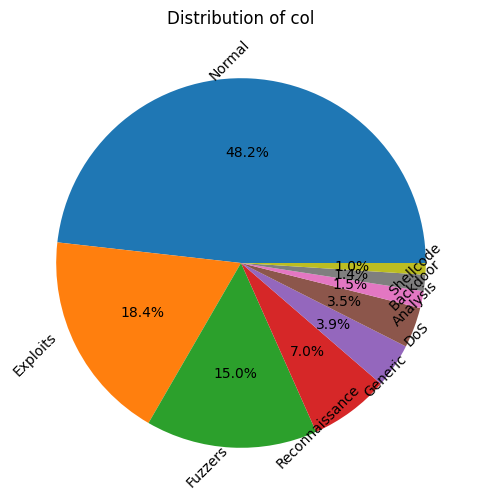

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = y_train.value_counts()
threshold = 0.01  # 1%

# Convert to proportions
proportions = counts / counts.sum()

# Group small categories
large = counts[proportions >= threshold]
small = counts[proportions < threshold]

if not small.empty:
    large["Others"] = small.sum()

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    large,
    labels=large.index,
    autopct='%1.1f%%',
)

for text in texts:
    text.set_rotation(45)
    text.set_ha('right')

plt.title('Distribution of col')
plt.ylabel('')
plt.show()

# Outputting dataset as a zip

In [136]:
import os

# Config
OUTPUT_DIR = "data/processed/2015"
TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
TEST_DIR = os.path.join(OUTPUT_DIR, "test")

SEED = 42

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

CLASSES = train_features["attack_cat"].unique()

for cls in CLASSES:

    #train_df rows with class cls from train
    train_df = train_features[train_features["attack_cat"] == cls]
    #test_df rows with class cls from test
    test_df = test_features[test_features["attack_cat"] == cls]

    train_path = os.path.join(TRAIN_DIR, f"{cls}.csv")
    test_path = os.path.join(TEST_DIR, f"{cls}.csv")

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(
        f"Class {cls:15s} | "
        f"Train: {train_df.shape[0]:6d} | "
        f"Test: {test_df.shape[0]:6d}"
    )

Class Normal          | Train:  51890 | Test:  34206
Class Backdoor        | Train:   1535 | Test:    346
Class Analysis        | Train:   1594 | Test:    446
Class Fuzzers         | Train:  16150 | Test:   4838
Class Shellcode       | Train:   1091 | Test:    378
Class Reconnaissance  | Train:   7522 | Test:   2703
Class Exploits        | Train:  19844 | Test:   7609
Class DoS             | Train:   3806 | Test:   1718
Class Generic         | Train:   4181 | Test:   3657


In [137]:
%cd data/processed
!zip -r 2015.zip 2015
%cd ../..


/content/cil-intrusion-detection/data/processed
  adding: 2015/ (stored 0%)
  adding: 2015/train/ (stored 0%)
  adding: 2015/train/Exploits.csv (deflated 61%)
  adding: 2015/train/Shellcode.csv (deflated 70%)
  adding: 2015/train/Normal.csv (deflated 67%)
  adding: 2015/train/Generic.csv (deflated 86%)
  adding: 2015/train/Fuzzers.csv (deflated 66%)
  adding: 2015/train/Backdoor.csv (deflated 82%)
  adding: 2015/train/Reconnaissance.csv (deflated 70%)
  adding: 2015/train/DoS.csv (deflated 67%)
  adding: 2015/train/Analysis.csv (deflated 81%)
  adding: 2015/test/ (stored 0%)
  adding: 2015/test/Exploits.csv (deflated 61%)
  adding: 2015/test/Shellcode.csv (deflated 69%)
  adding: 2015/test/Normal.csv (deflated 67%)
  adding: 2015/test/Generic.csv (deflated 85%)
  adding: 2015/test/Fuzzers.csv (deflated 66%)
  adding: 2015/test/Backdoor.csv (deflated 83%)
  adding: 2015/test/Reconnaissance.csv (deflated 70%)
  adding: 2015/test/DoS.csv (deflated 66%)
  adding: 2015/test/Analysis.csv (de

In [138]:
!git remote set-url origin https://{token}@github.com/esthy13/cil-intrusion-detection.git
!git add .
!git status
!git commit -m "Fixing 2015 dataset zipping"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   data/processed/2015.zip
	deleted:    data/processed/data/processed/2015/test/Analysis.csv
	deleted:    data/processed/data/processed/2015/test/Backdoor.csv
	deleted:    data/processed/data/processed/2015/test/DoS.csv
	deleted:    data/processed/data/processed/2015/test/Exploits.csv
	deleted:    data/processed/data/processed/2015/test/Fuzzers.csv
	deleted:    data/processed/data/processed/2015/test/Generic.csv
	deleted:    data/processed/data/processed/2015/test/Normal.csv
	deleted:    data/processed/data/processed/2015/test/Reconnaissance.csv
	deleted:    data/processed/data/processed/2015/test/Shellcode.csv
	deleted:    data/processed/data/processed/2015/train/Analysis.csv
	deleted:    data/processed/data/processed/2015/train/Backdoor.csv
	deleted:    data/processed/data/processed/2015/train/DoS.csv
	deleted:    data/processed/data/pro

In [139]:
%cd ..

/content


Labels

The dataset contains two label-related columns:

label: a binary label where 0 represents normal traffic and 1 represents attack traffic.

attack_cat: a multi-class label indicating the specific attack category.

Since the project focuses on Class-Incremental Learning, the attack_cat column is used as the target variable, as it allows the model to learn and expand its knowledge of different attack types over time. The label column is not used for training but is retained for reference and potential auxiliary analysis.

The dataset includes 9 attack categories plus normal traffic, with a highly imbalanced class distribution. In particular, some classes such as Worms contain very few samples, making the dataset well suited for studying catastrophic forgetting and incremental learning behavior.

Data Quality

The exploratory analysis showed that:

There are no missing values in the dataset.

There are no infinite or invalid numerical values.

There are no constant columns.

As a result, no imputation or numerical sanitization is required before preprocessing.

Feature Types

Among the 45 columns:

41 features are numerical, representing flow statistics, packet counts, byte counts, and other network behavior indicators.

3 categorical features are used as input features:

proto

service

state

The attack_cat and label columns are treated as labels and excluded from the feature set.

Preprocessing Decisions

Based on the exploration:

The id column is removed, as it has no semantic meaning for learning.

Categorical features (proto, service, state) are encoded using one-hot encoding.

Numerical features are normalized using feature scaling.

The attack_cat column is used as the training target for the CIL scenario.

These preprocessing decisions are fixed and applied consistently across all experiments.

Conclusion

The UNSW-NB15 dataset is clean, well structured, and provides clearly defined multi class attack labels, making it particularly suitable for class-incremental intrusion detection experiments. Its inherent class imbalance and presence of rare attack types further support its use for evaluating catastrophic forgetting and continual learning strategies.